# Task 2: Credit Risk Prediction

**Objective**

The objective of this project is to predict whether a loan applicant is likely to default or be approved based on applicant information such as income, education, loan amount, and credit history.

**Problem Statement**

Financial institutions need to assess loan applications carefully to reduce the risk of loan defaults. This project uses machine learning techniques to classify loan applicants based on their likelihood of loan approval.

**This project includes:**
- Data cleaning and handling missing values
- Exploratory Data Analysis (EDA)
- Classification using Logistic Regression
- Model evaluation using Accuracy and Confusion Matrix

**Dataset Understanding**

The dataset contains information about loan applicants.

Important Features:
- Gender
- Married
- Dependents
- Education
- Self_Employed
- ApplicantIncome
- CoapplicantIncome
- LoanAmount
- Credit_History
- Property_Area

Target Variable:
- Loan_Status

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

**Load Dataset**

In [3]:
df = pd.read_csv('loan_prediction.csv')

In [4]:
# Display first 5 records
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Dataset Information**

In [18]:
# Basic Dataset Information

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape:
(614, 13)

Column Names:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_H

In [5]:

# Check Missing Values

print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


**Data Cleaning and Preparation**

The dataset contains missing values in several columns.

To handle missing values:

- Numerical columns are filled using median values.
- Categorical columns are filled using mode values.

This helps preserve data quality and avoids losing records.

In [20]:
# Handle Missing Values

# Numerical Columns

df['LoanAmount'] = df['LoanAmount'].fillna(
    df['LoanAmount'].median()
)

# Categorical Columns

df['Gender'] = df['Gender'].fillna(
    df['Gender'].mode()[0]
)

df['Married'] = df['Married'].fillna(
    df['Married'].mode()[0]
)

df['Dependents'] = df['Dependents'].fillna(
    df['Dependents'].mode()[0]
)

df['Self_Employed'] = df['Self_Employed'].fillna(
    df['Self_Employed'].mode()[0]
)

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].mode()[0]
)

df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
)

# Verify Missing Values Again

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


**Exploratory Data Analysis (EDA)**

The purpose of EDA is to understand important patterns and distributions within the dataset.

The following visualizations are created:
1. Loan Amount Distribution
2. Education Distribution
3. Applicant Income Distribution

**Visualization**

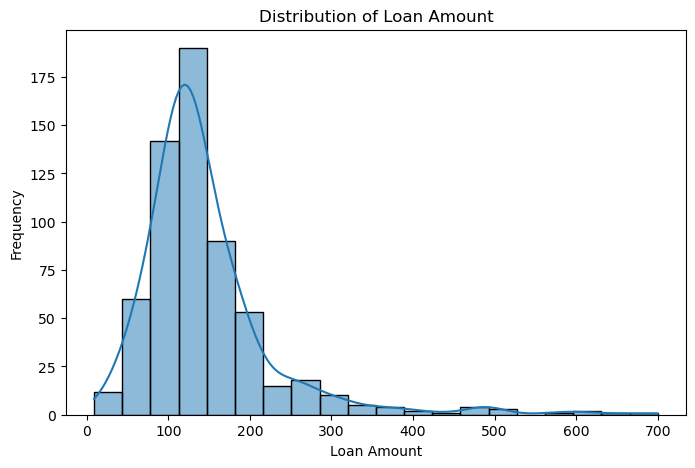

In [21]:
# Visualization 1
# Loan Amount Distribution


plt.figure(figsize=(8,5))

sns.histplot(
    df['LoanAmount'],
    bins=20,
    kde=True
)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

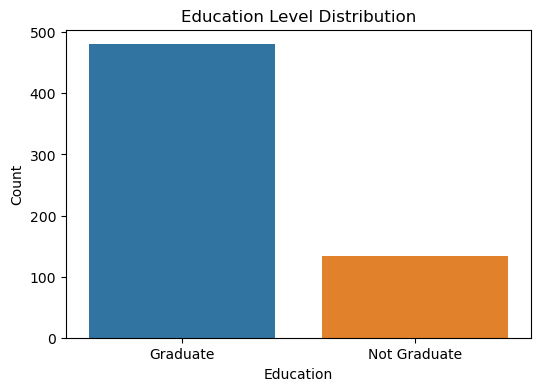

In [22]:
# Visualization 2
# Education Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Education'
)

plt.title("Education Level Distribution")
plt.xlabel("Education")
plt.ylabel("Count")

plt.show()

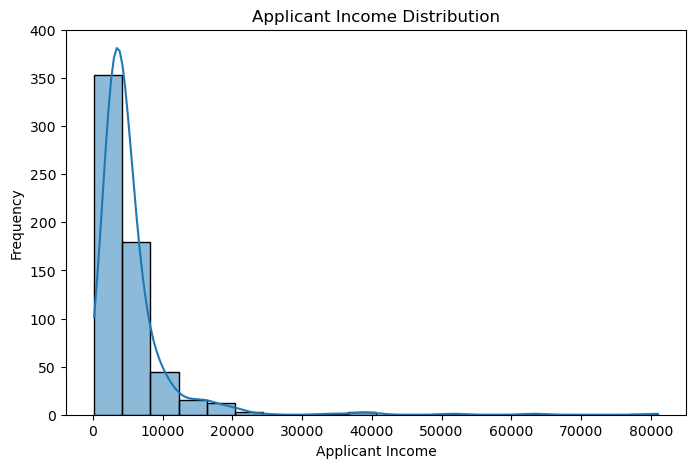

In [23]:
# Visualization 3
# Applicant Income Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['ApplicantIncome'],
    bins=20,
    kde=True
)

plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")

plt.show()

**Data Encoding**

Machine learning algorithms require numerical data.

Therefore, categorical variables are converted into numerical values using Label Encoding.

In [24]:
# Convert Categorical Variables

label_encoder = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = label_encoder.fit_transform(df[column])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


**Model Training and Testing**

A Logistic Regression model is used to predict loan approval status.

The dataset is divided into:
- Training Set (80%)
- Testing Set (20%)

In [25]:
# Separate Features and Target
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [26]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [27]:
# Train Logistic Regression Model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

**Model Evaluation**

The model performance is evaluated using:

- Accuracy Score
- Confusion Matrix

These metrics help measure how well the model predicts loan approval.

In [28]:
# Accuracy Score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7886178861788617



**Confusion Matrix**



In [29]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18 25]
 [ 1 79]]


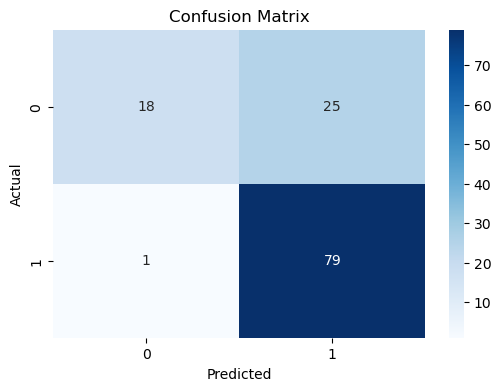

In [30]:
# Visualize Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Conclusion**

In this project, the Loan Prediction dataset was analyzed and cleaned by handling missing values appropriately.

Exploratory Data Analysis was performed to understand the distribution of loan amount, education level, and applicant income.

A Logistic Regression model was trained to predict loan approval status. The model was evaluated using accuracy score and confusion matrix.

The results demonstrate how machine learning can be applied to credit risk assessment and loan approval prediction using applicant information.